# **Predictive Modelling for Credit Card Default Using Machine Learning**
**Project Overview**

This project aims to predict credit card payment defaults, enabling banks to identify high-risk customers and intervene before defaults occur. Utilizing the Credit Card Default dataset, it focuses on constructing a machine learning model to predict whether a customer will default (1) or not (0) within the next month. The notebook comprises five major tasks: data understanding, exploratory data analysis, data preprocessing, model training & evaluation, and model interpretation using SHAP. Early prediction of defaults is crucial for minimizing financial losses and enhancing credit policies, aiding in more informed lending decisions.

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, precision_recall_curve)

from imblearn.over_sampling import SMOTE
import shap
import time
import warnings
warnings.filterwarnings('ignore')

# **Dataset Overview & Initial Preprocessing**


*   The dataset is used to predict whether a credit card client will default on their payment in the next month, making it a binary classification problem in the financial risk domain.
*   It comes from a credit card default dataset (Credit_Card.csv) and contains 34,788 records and 30 features, including demographic information, credit limits, billing amounts, and repayment history

*   The target variable is default.payment.next.month, where 1 indicates a default (fraud/risk) and 0 indicates no default, which is the key outcome the model aims to predict.

# **Data Quality Checks**

*   Checking for missing values using .isnull().sum() is one of the first steps to identify incomplete or corrupted data that may affect model performance and require cleani
*   Inspecting data types (.dtypes) ensures that each feature is correctly interpreted (e.g., numerical vs categorical), which is important for preprocessing and model training.

# **Data Loading Considerations**


*   The dataset uses a semicolon (;) as a separator, so sep=';' is required when loading it with pandas, otherwise the entire row would be read as a single column.
*   The parameter low_memory=False is used to avoid DtypeWarning issues caused by mixed data types in columns, ensuring pandas reads the dataset more consistently in one go instead of in chunks.











In [ ]:
#Loading the dataset and Description of Dataset
df = pd.read_csv('/content/drive/MyDrive/BSBI/Introduction To AI /Assignment/Assignement_Practical/Code and Data final/Credit_Card.csv', sep=';', low_memory=False)
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(34788, 30)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE   AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0  2.0        2.0       NaN  24.0      2      2     -1     -1   
1   2   120000.0  2.0        2.0       2.0  26.0     -1      2      0      0   
2   3    90000.0  2.0        2.0       2.0  34.0      0      0      0      0   
3   4    50000.0  2.0        2.0       1.0  37.0      0      0      0      0   
4   5    50000.0  1.0        2.0       1.0  57.0     -1      0     -1      0   

   ...  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  \
0  ...       0.0       0.0       0.0       0.0                           1   
1  ...    1000.0    1000.0       0.0    2000.0                           1   
2  ...    1000.0    1000.0    1000.0    5000.0                           0   
3  ...    1200.0    1100.0    1069.0    1000.0                           0   
4  ...   10000.0    9000.0     689.0     679.0                           0   

                risk_leak  BILL_AMT_SU

# **Task 1 — Exploratory Data Analysis**
**Class Imbalance & Its Impact**


*   The target variable shows a class imbalance, with approximately 81% non-default (0) and 19% default (1), meaning most customers do not default.
*   This imbalance is problematic because a model could achieve ~81% accuracy by always predicting “no default”, while completely failing to identify actual defaulters.


*   Therefore, accuracy alone is misleading, and metrics like recall, precision, and F1-score become more important.

**Insights from Descriptive Statistics**


*   The feature LIMIT_BAL has a very wide range (10,000 to 5,600,000) and a high standard deviation, indicating large variability in customer credit limits across the dataset.
*   This suggests the dataset includes both low-credit and very high-credit clients, which may require scaling or normalization.

**Understanding BILL_AMT_SUM**

The negative minimum value in BILL_AMT_SUM (-336,259) suggests that some customers are owed money by the bank due to overpayments or credit balances, reflecting realistic scenarios such as refunds or advance payments.







In [ ]:
# target variable distribution
print(df['default.payment.next.month'].value_counts())
print(df['default.payment.next.month'].value_counts(normalize=True).round(3))

default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64
default.payment.next.month
0    0.809
1    0.191
Name: proportion, dtype: float64
        LIMIT_BAL       AGE  BILL_AMT_SUM   PAY_AMT1    PAY_AMT2
count    33079.00  33033.00      34788.00   33063.00    33044.00
mean    184668.99     35.52     294815.17    5772.82     6057.36
std     235931.93      9.24     571807.25   16917.88    25557.70
min      10000.00     21.00    -336259.00       0.00        0.00
25%      60000.00     28.00      29738.25    1000.00      900.00
50%     140000.00     34.00     129037.00    2160.00     2019.00
75%     240000.00     41.00     350209.50    5034.00     5000.00
max    5600000.00     79.00   21292660.00  873552.00  1684259.00


In [ ]:
# descriptive statistics for key numerical features
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'PAY_AMT1', 'PAY_AMT2']
print(df[num_cols].describe().round(2))

        LIMIT_BAL       AGE  BILL_AMT_SUM   PAY_AMT1    PAY_AMT2
count    33079.00  33033.00      34788.00   33063.00    33044.00
mean    184668.99     35.52     294815.17    5772.82     6057.36
std     235931.93      9.24     571807.25   16917.88    25557.70
min      10000.00     21.00    -336259.00       0.00        0.00
25%      60000.00     28.00      29738.25    1000.00      900.00
50%     140000.00     34.00     129037.00    2160.00     2019.00
75%     240000.00     41.00     350209.50    5034.00     5000.00
max    5600000.00     79.00   21292660.00  873552.00  1684259.00


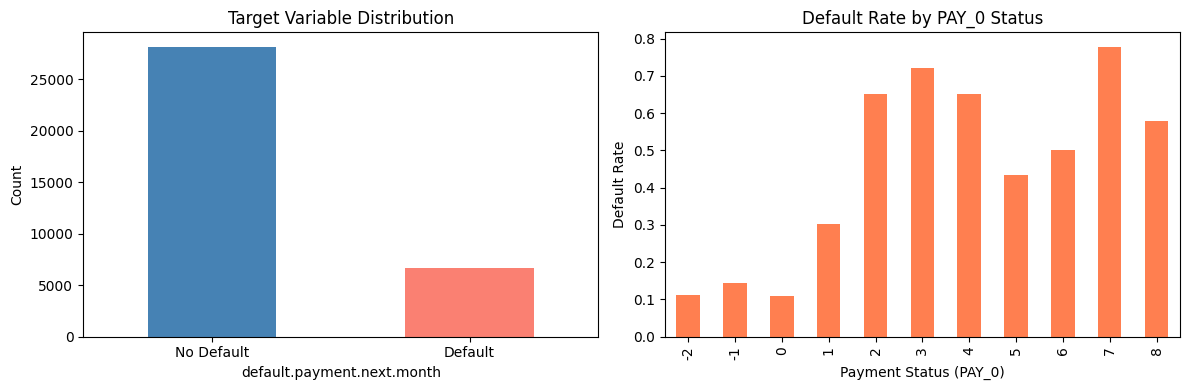

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['default.payment.next.month'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon']
)
axes[0].set_title('Target Variable Distribution')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel('Count')

pay0_default = df.groupby('PAY_0')['default.payment.next.month'].mean()
pay0_default.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Default Rate by PAY_0 Status')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('Payment Status (PAY_0)')

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150)
plt.show()

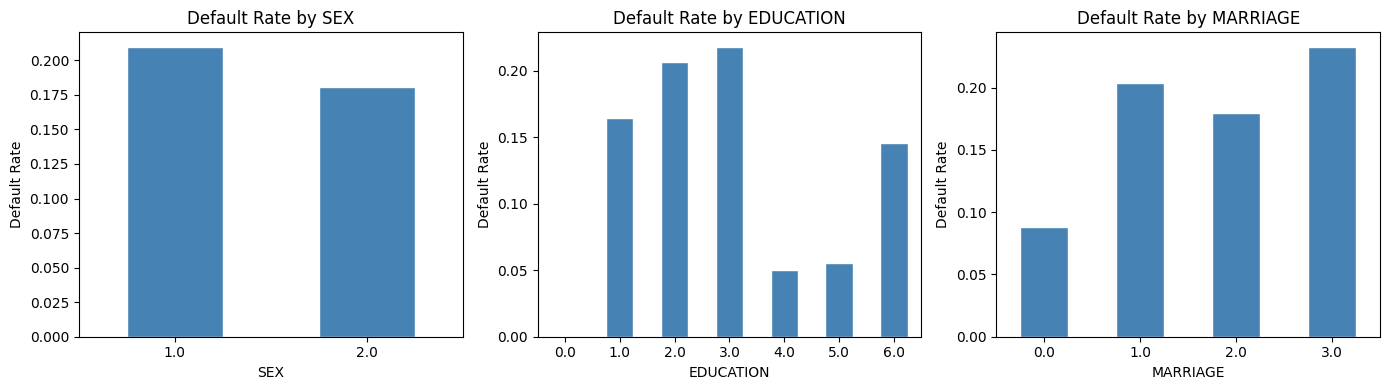

In [ ]:
# categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    df.groupby(col)['default.payment.next.month'].mean().plot(
        kind='bar', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150)
plt.show()

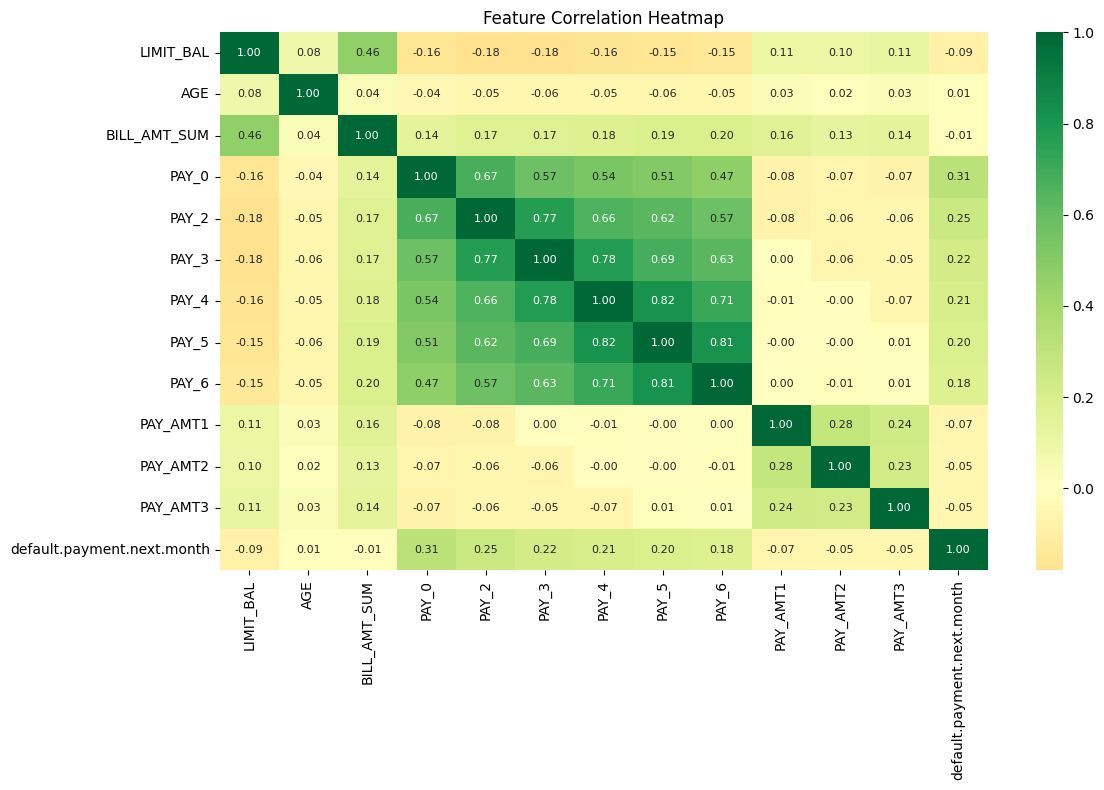

In [ ]:
# correlation heatmap
corr_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM',
             'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
             'PAY_AMT1','PAY_AMT2','PAY_AMT3',
             'default.payment.next.month']
plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

In [ ]:
# payment history correlation with target
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
for col in pay_cols:
    corr = df[col].corr(df['default.payment.next.month'])
    print(f"{col}: {corr:.4f}")

PAY_0: 0.3142
PAY_2: 0.2538
PAY_3: 0.2249
PAY_4: 0.2076
PAY_5: 0.1963
PAY_6: 0.1793


**Key EDA Insights from Payment History & Features**


*   The PAY_0 bar chart shows a sharp increase in default risk as payment status worsens, rising from around ~11% at 0 (on-time) to ~65% at 2 (2 months delay), clearly indicating that recent delays strongly signal default.
*   A temporal decay pattern is observed in correlations, where PAY_0 has the highest correlation (0.31) with default, and this gradually decreases through PAY_6 (0.18), meaning recent payment behavior is more predictive than older history.


*   The heatmap reveals high multicollinearity among PAY variables (e.g., PAY_2–PAY_6 strongly correlated), which can be problematic for models like Logistic Regression as it destabilizes coefficient estimates.
*   The slight negative correlation of LIMIT_BAL with default (-0.09) suggests that customers with higher credit limits are generally less likely to default, likely reflecting better financial stability.


*   The categorical plots show small differences in default rates across SEX, but more noticeable variation across EDUCATION and MARRIAGE, indicating these features may carry some predictive signal.
*   However, undocumented categories such as EDUCATION (0, 5, 6) and MARRIAGE (0) suggest data quality issues or encoding inconsistencies, which need to be handled carefully during preprocessing.
The CITY feature was dropped because it is high-cardinality with limited predictive power and could introduce noise or unnecessary complexity without improving model performance.







# **Task 2 — Data Preparation**


In [ ]:
# fixing undocumented categories
df['EDUCATION'] = df['EDUCATION'].replace({0.0: 4.0, 5.0: 4.0, 6.0: 4.0})
df['MARRIAGE'] = df['MARRIAGE'].replace({0.0: 3.0})

In [ ]:
# dropping leakage and irrelevant columns
cols_to_drop = ['ID', 'risk_leak', 'RISK_RATING',
                'LIMIT_BAL_LOG', 'CITY',
                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

target = 'default.payment.next.month'
X = df.drop(columns=cols_to_drop + [target])
y = df[target]

In [ ]:
# imputing missing values
median_cols = ['LIMIT_BAL', 'AGE', 'PAY_AMT1', 'PAY_AMT2', 'BILL_AMT_SUM']
mode_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

X[median_cols] = median_imputer.fit_transform(X[median_cols])
X[mode_cols] = mode_imputer.fit_transform(X[mode_cols])

print("Missing values after imputation:", X.isnull().sum().sum())
print("Feature set shape:", X.shape)

Missing values after imputation: 0
Feature set shape: (34788, 18)


In [ ]:
# train/test split before scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train default rate:", y_train.mean().round(3))
print("Test default rate:", y_test.mean().round(3))

Train default rate: 0.191
Test default rate: 0.191


In [ ]:
# scaling after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# SMOTE for KNN only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

After SMOTE: {1: 22505, 0: 22505}


**Data Cleaning & Preprocessing Decisions**


*   The features risk_leak and RISK_RATING were dropped because they showed near-perfect separation of the target variable, indicating data leakage, which would lead to unrealistically high model performance.
*   The individual BILL_AMT1–6 columns were removed because BILL_AMT_SUM already represents their combined total, reducing redundancy and dimensionality without losing information.

*   Undocumented categories in EDUCATION (0, 5, 6) and MARRIAGE (0) were grouped into an “others” category to handle inconsistencies and avoid misleading the model with undefined values.
*   Instead of dropping missing values (which would remove over 10,000 rows, ~30% of the dataset), imputation was used to preserve data size and maintain model robustness.


*   Median imputation was applied to numerical features to reduce the effect of outliers, while mode imputation was used for categorical features to retain the most common category.
*   The dataset was split into training and testing sets before scaling to prevent data leakage, since fitting the scaler on the full dataset would allow information from the test set to influence training.


*   Stratified splitting (stratify=y) was used to maintain the same class distribution (≈19% default) in both train and test sets, ensuring fair evaluation.
*   Finally, SMOTE was applied only to KNN because distance-based models are highly sensitive to class imbalance, whereas models like Random Forest can handle imbalance effectively using class weights.









# **Task 3 — Model Training**

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': CalibratedClassifierCV(
        LinearSVC(
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        )
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    )
}

In [ ]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()

    if name == 'KNN':
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_scaled, y_train)

    elapsed = time.time() - start
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy':            round(report['accuracy'], 4),
        'Precision (Default)': round(report['1']['precision'], 4),
        'Recall (Default)':    round(report['1']['recall'], 4),
        'F1 (Default)':        round(report['1']['f1-score'], 4),
        'AUC-ROC':             round(auc, 4)
    }
    print(f"  Done — AUC: {auc:.4f}")

results_df = pd.DataFrame(results).T
print(results_df)

Training Logistic Regression...
  Done — AUC: 0.7300
Training Decision Tree...
  Done — AUC: 0.7360
Training Random Forest...
  Done — AUC: 0.8750
Training SVM...
  Done — AUC: 0.7288
Training KNN...
  Done — AUC: 0.7350
                     Accuracy  Precision (Default)  Recall (Default)  \
Logistic Regression    0.6989               0.3462            0.6461   
Decision Tree          0.7715               0.4290            0.5875   
Random Forest          0.8554               0.8296            0.3073   
SVM                    0.8244               0.6627            0.1668   
KNN                    0.7297               0.3735            0.6101   

                     F1 (Default)  AUC-ROC  
Logistic Regression        0.4509   0.7300  
Decision Tree              0.4959   0.7360  
Random Forest              0.4485   0.8750  
SVM                        0.2665   0.7288  
KNN                        0.4633   0.7350  


**Model Selection & Justification**


*   Here five models are used to cover different learning styles suited to this dataset: Logistic Regression for linear patterns, Decision Tree and Random Forest for non-linear relationships, SVM for high-dimensional structured data, and KNN as a distance-based approach sensitive to local patterns.
*   Here Logistic Regression serves as a strong linear baseline because many features (like payment delays and aggregated billing) have monotonic relationships with default, making it a good reference point despite some non-linearity.


*   Here the Decision Tree captures non-linear interactions and feature splits effectively, but it risks overfitting, which was controlled using max_depth=10 to limit complexity and improve generalisation.
*   Here Random Forest improves upon Decision Trees by averaging multiple trees, reducing variance and overfitting, while also handling mixed feature types and interactions well—reflected in its strong AUC performance.


*  Here SVM uses LinearSVC instead of an RBF kernel due to computational efficiency, as non-linear kernels scale poorly with larger datasets like this one as RBF kernel is best suited for small datasets which are less complex.
*   Here KNN is included despite its limitations because it provides a useful comparison as a distance-based model and helps highlight the effect of feature scaling and class imbalance handling (via SMOTE).


*   The parameter class_weight='balanced' is used across most models to address class imbalance by penalising misclassification of the minority (default) class more heavily.
*   Finally, recall is prioritised over accuracy because in banking, missing a defaulter (false negative) is far more costly than incorrectly flagging a non-defaulter (false positive).











# **Task 4 — Evaluation and Visualisation.**

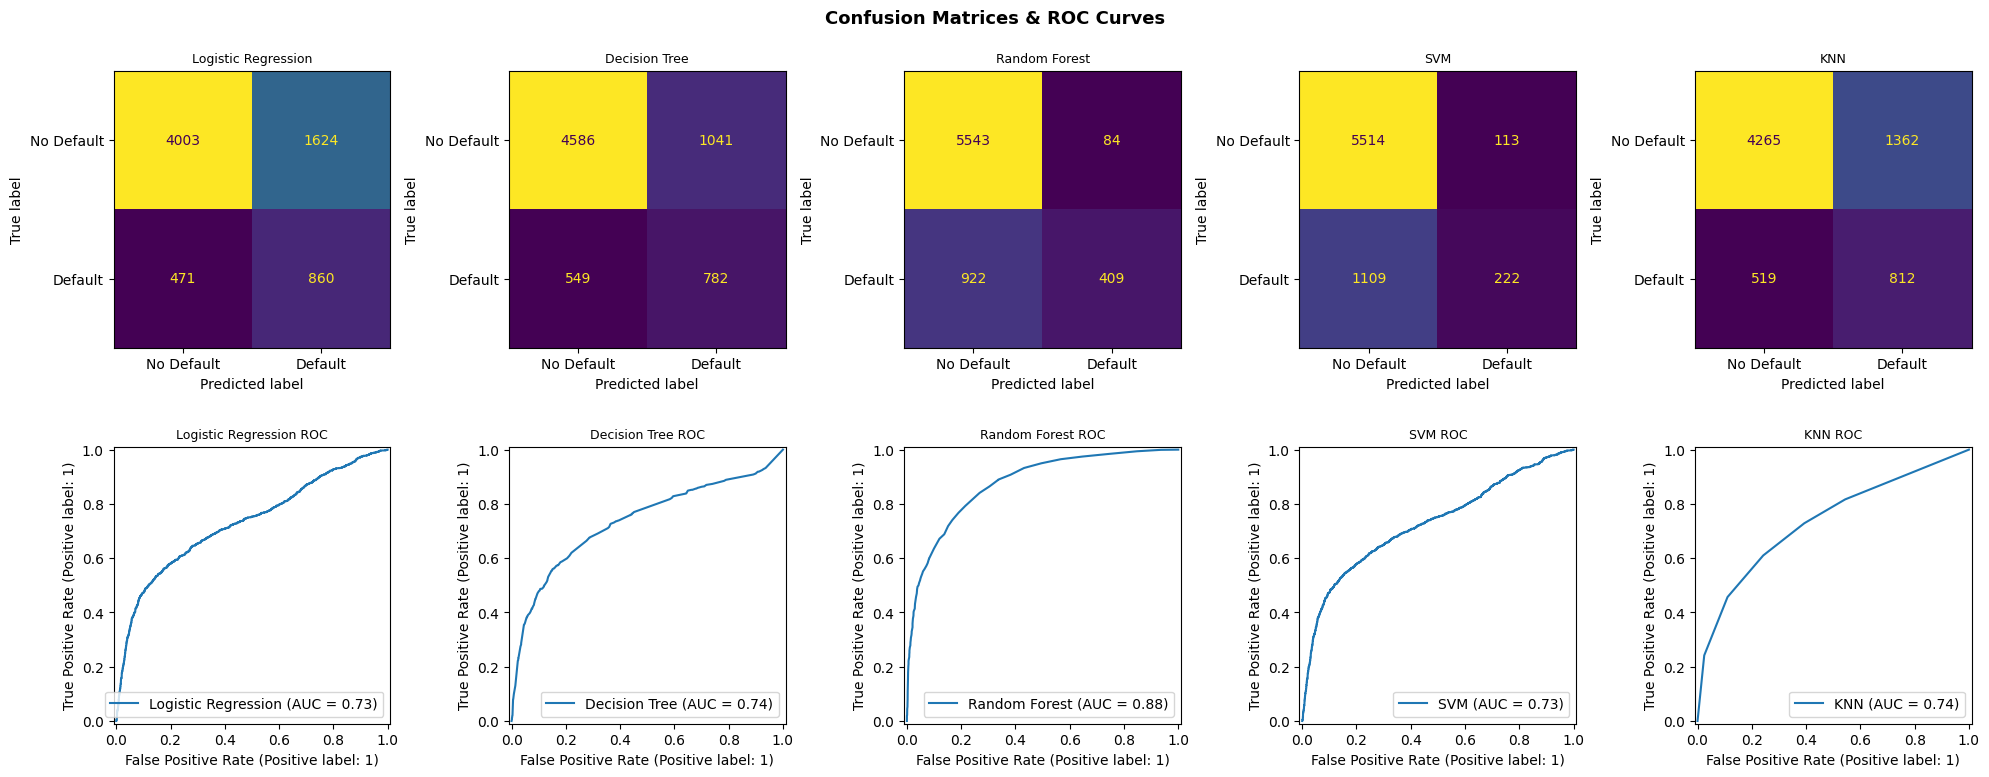

In [ ]:
#Plotting Confusion matrices and ROC curves
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm,
        display_labels=['No Default','Default']).plot(
        ax=axes[0, idx], colorbar=False)
    axes[0, idx].set_title(f'{name}', fontsize=9)

    RocCurveDisplay.from_predictions(
        y_test, y_prob, ax=axes[1, idx], name=name)
    axes[1, idx].set_title(f'{name} ROC', fontsize=9)

plt.suptitle('Confusion Matrices & ROC Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

In [ ]:
#Threshold tuning
rf_model = models['Random Forest']
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
optimal_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_optimal = (y_prob_rf >= optimal_threshold).astype(int)

print("\n--- Default threshold (0.5) ---")
print(classification_report(y_test,
      rf_model.predict(X_test_scaled),
      target_names=['No Default', 'Default']))

print(f"\n--- Optimal threshold ({optimal_threshold:.4f}) ---")
print(classification_report(y_test, y_pred_optimal,
      target_names=['No Default', 'Default']))

Optimal threshold: 0.1938

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

  No Default       0.86      0.99      0.92      5627
     Default       0.83      0.31      0.45      1331

    accuracy                           0.86      6958
   macro avg       0.84      0.65      0.68      6958
weighted avg       0.85      0.86      0.83      6958


--- Optimal threshold (0.1938) ---
              precision    recall  f1-score   support

  No Default       0.91      0.90      0.91      5627
     Default       0.60      0.64      0.62      1331

    accuracy                           0.85      6958
   macro avg       0.76      0.77      0.76      6958
weighted avg       0.85      0.85      0.85      6958



In [ ]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)
y_prob_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_tuned,
      target_names=['No Default', 'Default']))
print("Tuned AUC-ROC:", round(roc_auc_score(y_test, y_prob_tuned), 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC: 0.7736
              precision    recall  f1-score   support

  No Default       0.89      0.87      0.88      5627
     Default       0.51      0.56      0.53      1331

    accuracy                           0.81      6958
   macro avg       0.70      0.72      0.71      6958
weighted avg       0.82      0.81      0.82      6958

Tuned AUC-ROC: 0.7941


**Model Evaluation & Final Selection**


*   The results table showed that Random Forest achieved the highest AUC (~ 0.875) and overall accuracy (~ 85%), while Logistic Regression and KNN performed better on recall (~ 0.64 and ~0.61), and SVM had the weakest recall despite decent accuracy.
*   However, accuracy is misleading in this imbalanced setting—Random Forest’s 85% accuracy came with only ~32% recall, meaning it missed most actual defaulters, which is risky in a banking context.


*   The confusion matrix confirmed that Random Forest was too conservative, correctly identifying non-defaulters but failing to flag many actual defaults (high false negatives).
*   By applying threshold tuning, recall improved significantly from 0.32 to 0.64 by lowering the decision threshold from 0.5 to ~0.19, allowing the model to capture more defaulters.



*   GridSearchCV resulted in worse test performance despite a better cross-validation AUC, likely due to overfitting to validation folds and reduced generalisation on unseen data.
*   Therefore, Random Forest with threshold tuning was selected as the final model, as it combines strong ranking ability (high AUC) with improved recall after adjustment.


*   At the optimal threshold, there is a clear precision–recall tradeoff, where recall increases substantially but precision drops (from ~0.83 to ~0.60), which is acceptable in fraud detection.
*   Finally, AUC-ROC is a better metric than accuracy here because it evaluates the model’s ability to distinguish between classes across all thresholds, which is crucial for imbalanced problems like default prediction.









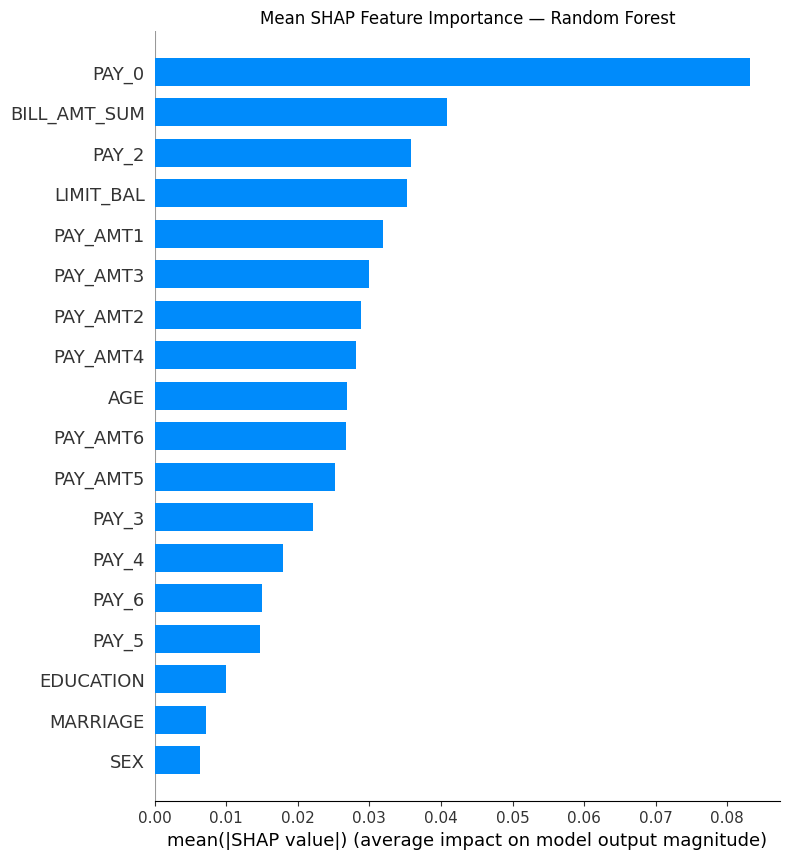

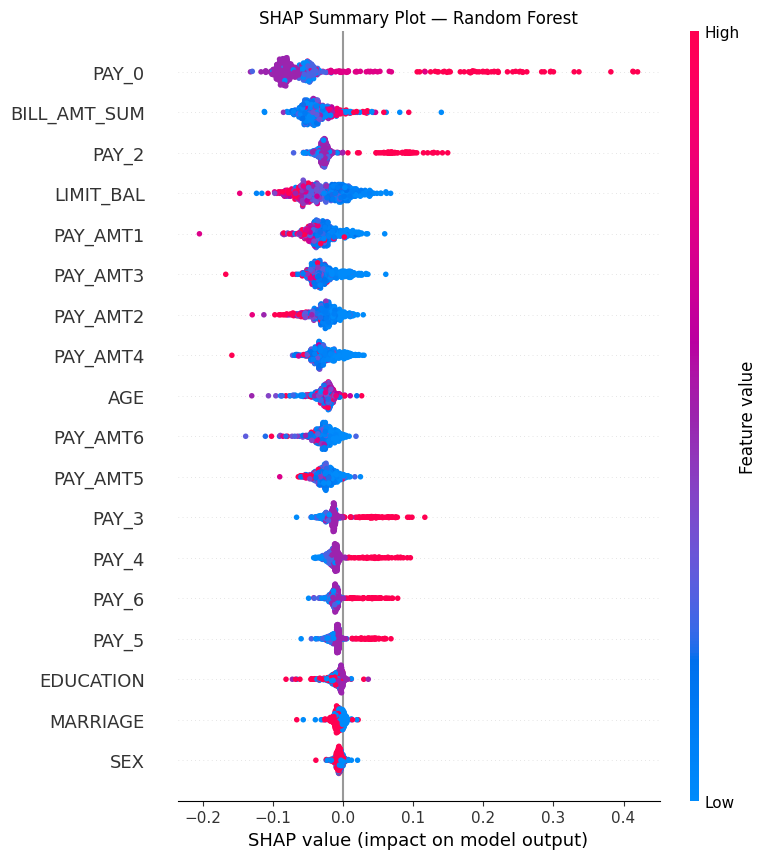

In [ ]:
#SHAP Analysis
explainer = shap.TreeExplainer(rf_model)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
shap_sample = X_test_df.sample(500, random_state=42)
shap_values_raw = explainer.shap_values(shap_sample)

if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
else:
    shap_vals = shap_values_raw[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, shap_sample,
                  plot_type='bar', show=False)
plt.title('Mean SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, shap_sample, show=False)
plt.title('SHAP Summary Plot — Random Forest')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

**SHAP Interpretation & Feature Insights**


*   SHAP (SHapley Additive exPlanations) is a model interpretation technique that explains how each feature contributes to a prediction, making complex models like Random Forest more transparent and trustworthy.

*   The bar plot shows that the top 5 most important features are PAY_0, BILL_AMT_SUM, PAY_2, LIMIT_BAL, and PAY_AMT1, confirming that recent payment behavior and financial activity are key drivers of default risk.


*   In the beeswarm plot, PAY_0 shows a clear directional impact, where red dots (high delay values) push predictions strongly toward default (positive SHAP values), while blue dots (on-time payments) push predictions toward non-default.
*   For LIMIT_BAL, the SHAP distribution shows a negative relationship with default, meaning higher credit limits (red) tend to reduce default risk, aligning with the idea that financially stable clients are less risky.



*   Interestingly, BILL_AMT_SUM ranks second in importance despite having near-zero linear correlation, suggesting it captures non-linear patterns or interactions that traditional correlation analysis cannot detect.
*   The bottom features (SEX, MARRIAGE, EDUCATION) have very low SHAP importance, indicating that demographic factors have minimal influence on predictions compared to behavioral financial features.


*   Overall, SHAP largely validated the EDA findings (importance of PAY features and LIMIT_BAL), while also revealing deeper non-linear relationships like the role of BILL_AMT_SUM.
*   From an ethical perspective, the inclusion of SEX in the model raises concerns, and given its near-zero importance, there is a strong argument for removing it to avoid potential bias without sacrificing performance.







